<a href="https://colab.research.google.com/github/pri-2711/qiskit_codes/blob/main/Qiskit_code_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=42d0ce8db768af2cb451541cc2c7382e575ba91b4e133f693908193e4d33695c
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit import __version__
print(__version__)

2.4.1


In [ ]:
import numpy as np
#Dirac notations -> KET - column vector
ket0=np.array([[1],[0]])
ket1=np.array([[0],[1]])
print("Average of 2 = ",ket0 / 2 + ket1 / 2)

Average of 2 =  [[0.5]
 [0.5]]


In [ ]:
M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])
M = M1 / 2 + M2 / 2
print("Matrix average= ",M)

Matrix average=  [[1.  0.5]
 [0.  0.5]]


In [ ]:
#matrix multiplicaiton using '@' operator
print(M1 @ ket1)
print(M1 @ M2)
print(M @ M)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [ ]:
#same operation but using Qiskit (better visualization)
#latex => is way of documenting in more clean, clear manner
from qiskit.visualization import array_to_latex
display(array_to_latex(M1 @ ket1))
print('\n')
display(array_to_latex(M1 @ M2))
print('\n')
display(array_to_latex(M @ M) )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
#State vector class- to define, manipulate quantum state vectors
from qiskit.quantum_info import Statevector
from numpy import sqrt
u=Statevector([1/sqrt(2), 1/sqrt(2)])
v=Statevector([(1 + 2.0j) / 3, -2 / 3])
w=Statevector([1 / 3, 2 / 3])


In [ ]:
display(u.draw("text"))
print('\n')
display(u.draw("latex"))
print('\n')
print(u.draw("latex_source")) # latex code for above written equation
print('\n')
display(v.draw("latex"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>



\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle




<IPython.core.display.Latex object>

In [ ]:
#measure method -> standard basis measurement, collapsing of quantum system
outcome,state=v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
print('\n')
display(state.draw("latex"))

Measured: 0
Post-measurement state:




<IPython.core.display.Latex object>

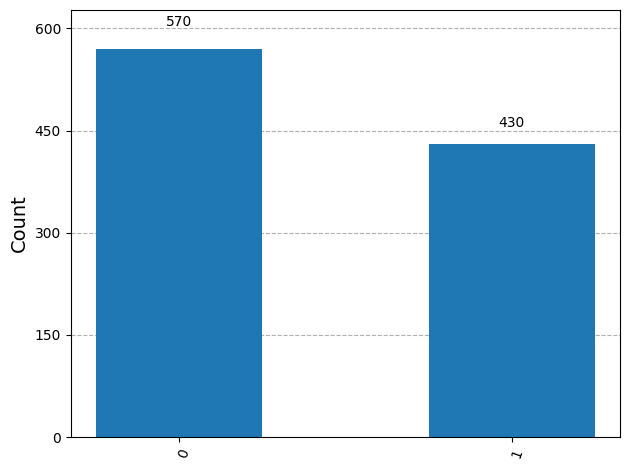

In [ ]:
#Sample counts - allows simulation of any number of measurements on system to start with fresh copy of state
#measures same state n no.of times but results in diff probabilities
from qiskit.visualization import plot_histogram
stat=v.sample_counts(1000)
plot_histogram(stat)

In [ ]:
#to define Unitary Operations
from qiskit.quantum_info import Operator
Y = Operator([[0, -1.0j], [1.0j, 0]])
display(Y.draw("latex"))
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
display(H.draw("latex"))
S = Operator([[1, 0], [0, 1.0j]])
display(S.draw("latex"))
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])
display(T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
#to perform Unitary operations on states
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

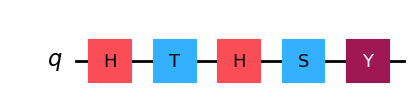

In [ ]:
#making quantum circuits
from qiskit import QuantumCircuit
circuit = QuantumCircuit(1)
circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))
#mpl - short for matplotlib : used as renderer to show output of circuit
#other types of renderers : text-based, latex-based

In [ ]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

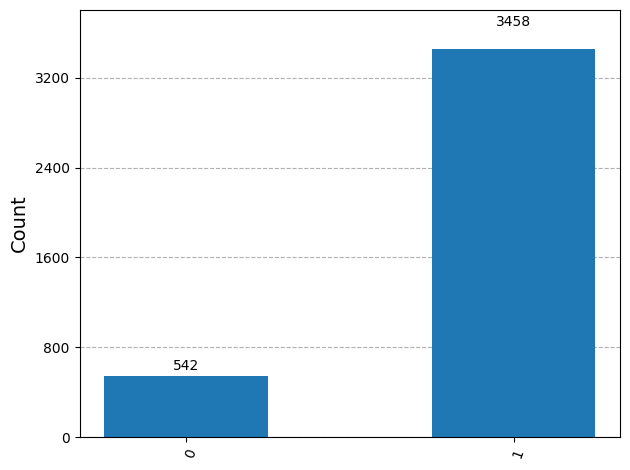

In [ ]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))